In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import pyproj
from pyproj import Transformer
from datetime import datetime, timedelta
import os, fnmatch, glob
import cmocean 
import rasterio
from rasterio.plot import show
import sys
import geopy.distance
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
startdate = datetime.strptime('2024-04-04 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-04-19 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/SvalMIZ2024data/colocatedFiles/final/dataset_temp.nc'
ifiledrift    = '/home/maltem/work/python/SvalMIZ2024data/colocatedFiles/final/dataset_trajectories_full.nc'

In [3]:
OMBtemp = xr.open_mfdataset(ifiletemp)


In [4]:
flag3 = OMBtemp.ssdr[5,0,buoy,:].values
arr_series = pd.Series(flag3)
# Interpolate missing values
flag3 = arr_series.interpolate(method='linear').to_numpy()

NameError: name 'buoy' is not defined

In [5]:
flag3<100

NameError: name 'flag3' is not defined

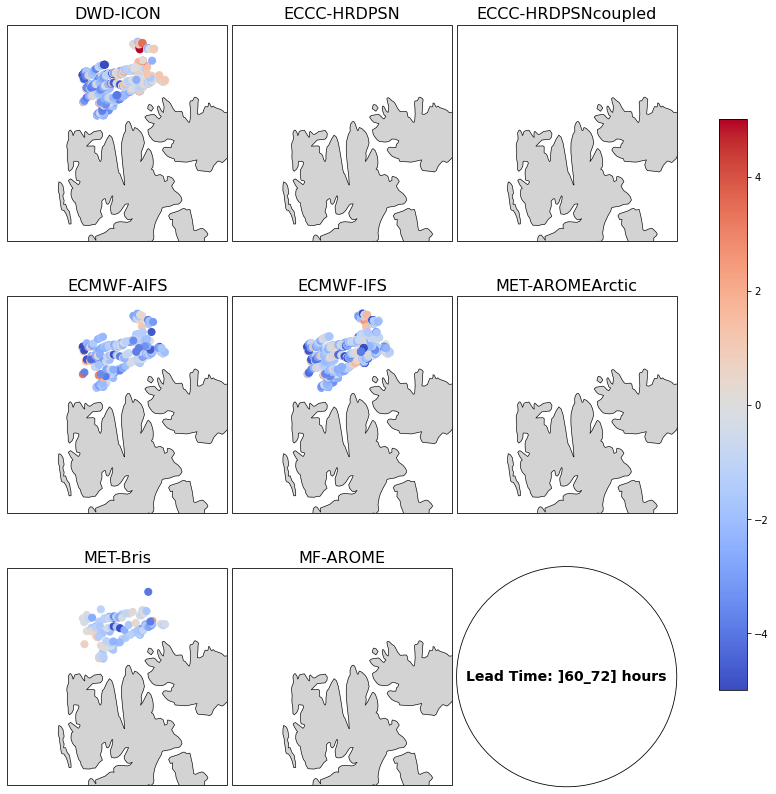

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Define projection with central longitude at 20°E
proj = ccrs.NorthPolarStereo(central_longitude=20)

#fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})
# Create a 3x3 grid of subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15), subplot_kw={'projection': proj})
# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.02, hspace=0.0)  # Decrease these values to bring plots closer

rad_threshold = 100
    
time_ds = OMBtemp.time_ds

# Define the start and end dates
start_date = pd.Timestamp('2024-04-20T00:00:00')
end_date   = pd.Timestamp('2024-05-20T00:00:00')
model = 0
ldint = 5
time_mask = (time_ds >= start_date) & (time_ds <= end_date)



all_temp_1m =[]
all_temp_models={}

for model in range(9):
    row = model // 3
    col = model % 3
    ax = axs[row, col]
    
    all_temp_models[model] = []
   
    if model == 8:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        lead_time = f"Lead Time: {OMBtemp.lt_int[ldint].values} hours"
        ax.text(0.5, 0.5, lead_time, fontsize=14, ha='center', va='center', fontweight='bold', transform=ax.transAxes)
        

    else:
        ax.set_extent([7, 25, 78, 81.5], crs=ccrs.PlateCarree())  # Focus on Svalbard region
        ax.add_feature(cfeature.LAND.with_scale('50m'), color='lightgray')
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
        ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=":", linewidth=0.4)
    
        for buoy in range(len(OMBtemp.tr_nr)):
            
            
            flag3 = OMBtemp.ssdr[5,0,buoy,:].values
            # Radiation needs to be filled between the hours:
            arr_series = pd.Series(flag3)
            # Interpolate missing values
            flag3 = arr_series.interpolate(method='linear').to_numpy()
            
            flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & (flag3 < rad_threshold) & time_mask
            
            lat = OMBtemp.lat_obs[buoy, flag_condition.values]  # Latitude values
            lon = OMBtemp.lon_obs[buoy,flag_condition.values]  # Longitude values
            temp = OMBtemp.temp_1m_calibrated[buoy,flag_condition.values]-273.15# Temperature values
            tempmodel = OMBtemp.T2M[model, ldint , buoy, flag_condition.values]-273.15
            
            sc = ax.scatter(lon, lat, c=tempmodel-temp, cmap='coolwarm', s=50, transform=ccrs.PlateCarree(),vmin=-5, vmax=5)
        
            all_temp_models[model].append(tempmodel.values) 
            
            if model==0:
                all_temp_1m.append(temp.values)
        
        ax.set_title(f"{OMBtemp.model[model].values}",fontsize=16)
 

all_temp_1m = np.concatenate(all_temp_1m) if all_temp_1m else np.array([])    
all_temp_models_array=np.zeros([8,len(all_temp_1m)])
    
for model in range(8):
    
    tmp_array = all_temp_models[model]
    
    all_temp_models_array[model,:] = np.concatenate(tmp_array) if tmp_array else np.array([])    





# Add colorbar for the entire figure
fig.colorbar(sc, ax=axs, orientation="vertical", shrink=0.7, pad=0.05)
sc.set_label("Temperature Difference (°C)")
#plt.title('Leadtin')
# Show plot
plt.tight_layout   
# Construct filename
filename = f"temp_diff_{start_date}_to_{end_date}_leadtime_{ldint}.png"

# Save figure as PNG
plt.savefig(filename, dpi=300, bbox_inches='tight')


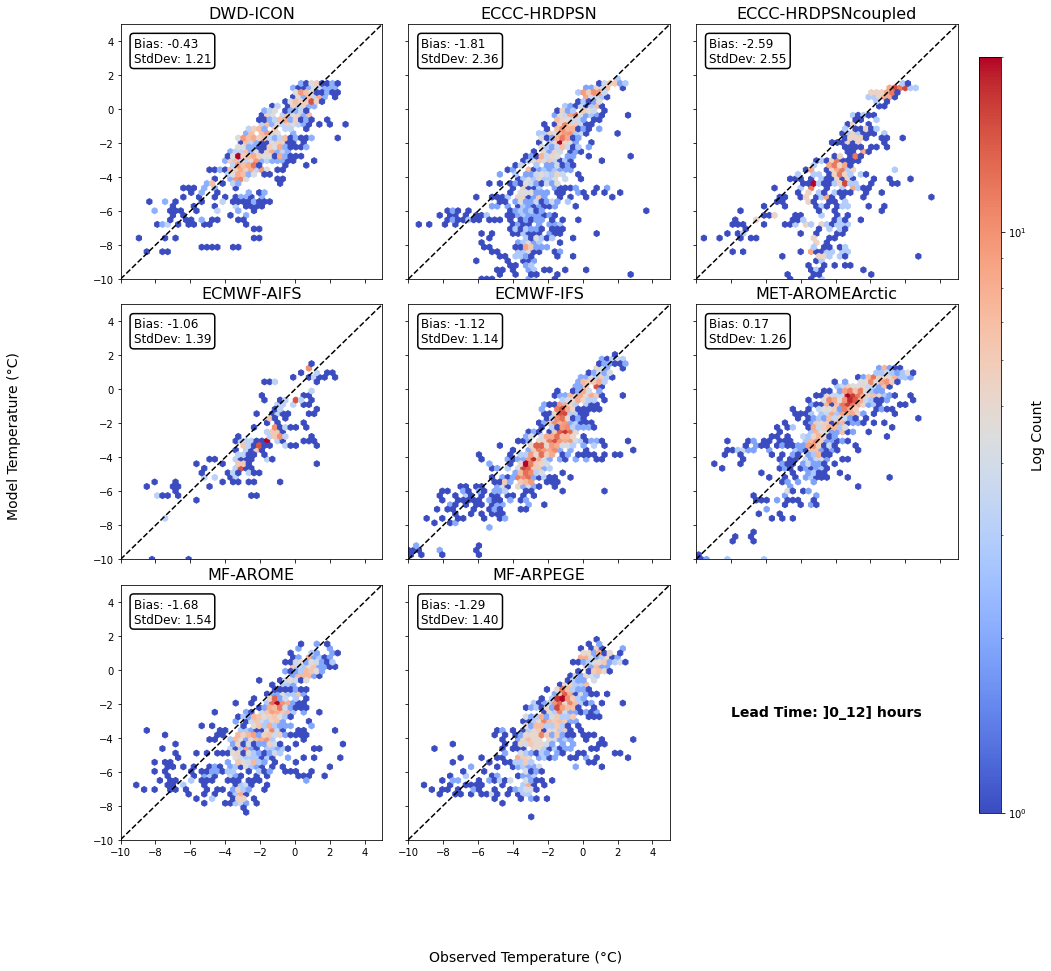

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define figure with 3x3 subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Adjust spacing

# Define the start and end dates
start_date = pd.Timestamp('2024-04-20T00:00:00')
end_date   = pd.Timestamp('2024-05-20T00:00:00')

ldint = 0
time_mask = (OMBtemp.time_ds >= start_date) & (OMBtemp.time_ds <= end_date)

# Storage arrays
all_temp_1m = []
all_temp_models = {}

for model in range(9):  # Loop over 9 models
    row, col = divmod(model, 3)  # Determine subplot position
    ax = axs[row, col]

    all_temp_models[model] = []  # Initialize storage

    if model == 8:  # Special case: last plot, add text
        ax.axis("off")  # Hide axes
        lead_time = f"Lead Time: {OMBtemp.lt_int[ldint].values} hours"
        ax.text(0.5, 0.5, lead_time, fontsize=14, ha='center', va='center', fontweight='bold', transform=ax.transAxes)
    else:
        for buoy in range(len(OMBtemp.tr_nr)):
            
            flag3 = OMBtemp.ssdr[5,0,buoy,:].values
            # Radiation needs to be filled between the hours:
            arr_series = pd.Series(flag3)
            # Interpolate missing values
            flag3 = arr_series.interpolate(method='linear').to_numpy()
            
            flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & (flag3 < rad_threshold) & time_mask
            
            #flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & time_mask

            temp = OMBtemp.temp_1m_calibrated[buoy, flag_condition.values] - 273.15
            tempmodel = OMBtemp.T2M[model, ldint, buoy, flag_condition.values] - 273.15

            all_temp_models[model].append(tempmodel.values)  # Store model temp
            
            if model == 0:  # Store observations only once
                all_temp_1m.append(temp.values)

        # Convert to 1D arrays and filter out NaN/Inf
        temp_obs_flat = np.concatenate(all_temp_1m) if all_temp_1m else np.array([])
        temp_model_flat = np.concatenate(all_temp_models[model]) if all_temp_models[model] else np.array([])

        # Remove NaN/Inf values
        valid_mask = np.isfinite(temp_obs_flat) & np.isfinite(temp_model_flat)
        temp_obs_flat = temp_obs_flat[valid_mask]
        temp_model_flat = temp_model_flat[valid_mask]

        # Ensure there is at least some data
        if len(temp_obs_flat) > 0 and len(temp_model_flat) > 0:
            # Calculate Bias and Standard Deviation
            bias = np.mean(temp_model_flat - temp_obs_flat)
            stde = np.std(temp_model_flat - temp_obs_flat)

            # Set equal axis limits
            temp_min = min(temp_obs_flat.min(), temp_model_flat.min()) - 1
            temp_max = max(temp_obs_flat.max(), temp_model_flat.max()) + 1
            temp_min = -10; temp_max=5
            ax.set_xlim(temp_min, temp_max)
            ax.set_ylim(temp_min, temp_max)

            # Scatter plot with color density (hexbin)
            hb = ax.hexbin(temp_obs_flat, temp_model_flat, gridsize=50, cmap='coolwarm', mincnt=1, bins='log', extent=[-10,5,-10,5])

            # Plot 1:1 diagonal reference line
            ax.plot([temp_min, temp_max], [temp_min, temp_max], 'k--', linewidth=1.5, label="1:1 Line")

            # Set axis labels
            ax.set_title(f"{OMBtemp.model[model].values}", fontsize=16)

            # Add text box with Bias and Standard Deviation
            textstr = f'Bias: {bias:.2f}\nStdDev: {stde:.2f}'
            props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.5)
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='left', bbox=props)

        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(0.5, 0.5, "No valid data", fontsize=14, ha='center', va='center', transform=ax.transAxes)

# Global labels
fig.supxlabel("Observed Temperature (°C)", fontsize=14)
fig.supylabel("Model Temperature (°C)", fontsize=14)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position colorbar
cbar = plt.colorbar(hb, cax=cbar_ax)
cbar.set_label("Log Count", fontsize=14)

# Save figure
filename = f"temp_vs_model_{start_date}_to_{end_date}_leadtime_{ldint}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

# Show plot
plt.show()


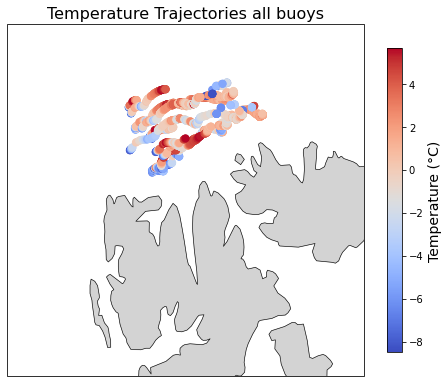

In [94]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Define projection with central longitude at 20°E
proj = ccrs.NorthPolarStereo(central_longitude=20)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})

# Add lower-resolution map features for faster rendering
ax.set_extent([7, 25, 78, 81.5], crs=ccrs.PlateCarree())  # Focus on Svalbard region
ax.add_feature(cfeature.LAND.with_scale('50m'), color='lightgray')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=":", linewidth=0.4)

time_ds = OMBtemp.time_ds

# Define the start and end dates
start_date = pd.Timestamp('2024-04-20T00:00:00')
end_date   = pd.Timestamp('2024-05-05T00:00:00')

time_mask = (time_ds >= start_date) & (time_ds <= end_date)



for buoy in range(len(OMBtemp.tr_nr)):
    
    flag3 = OMBtemp.ssdr[5,0,buoy,:].values
            # Radiation needs to be filled between the hours:
    arr_series = pd.Series(flag3)
 # Interpolate missing values
    flag3 = arr_series.interpolate(method='linear').to_numpy()
           
    flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & (flag3 < rad_threshold) & time_mask
       
    lat = OMBtemp.lat_obs[buoy, flag_condition.values]  # Latitude values
    lon = OMBtemp.lon_obs[buoy,flag_condition.values]  # Longitude values
    temp = OMBtemp.temp_1m_calibrated[buoy,flag_condition.values]-273.15# Temperature values
    #tempmodel = OMBtemp.T2M[model, ldint , buoy, flag_condition.values]-273.15
    # Scatter plot of data
    sc = ax.scatter(lon, lat, c=temp, cmap='coolwarm', s=50, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(sc, orientation="vertical", shrink=0.7, pad=0.05)
cbar.set_label("Temperature (°C)",fontsize=14)

# Title
ax.set_title("Temperature Trajectories all buoys",fontsize=16)

# Show plot
plt.show()

In [53]:
OMBtemp

<xarray.Dataset>
Dimensions:                      (tr_nr: 33, time_ds: 2929, model: 8, lt_int: 8)
Coordinates:
  * tr_nr                        (tr_nr) int64 1 2 3 4 6 7 ... 29 30 31 32 34 35
  * time_ds                      (time_ds) datetime64[ns] 2024-04-01 ... 2024...
  * model                        (model) object 'DWD-ICON' ... 'MF-ARPEGE'
  * lt_int                       (lt_int) object ']0_12]' ... ']84_96]'
Data variables: (12/31)
    lat_obs                      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    lon_obs                      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_1m_calibrated           (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_10cm_calibrated         (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_snowsurface_calibrated  (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_snowice_calibrated      (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    ...                           ...
    sldr                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(8, 8, 33, 2929), meta=np.ndarray>
    slur                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(8, 8, 33, 2929), meta=np.ndarray>
    ssdr                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(8, 8, 33, 2929), meta=np.ndarray>
    ssur                         (model, lt_int, tr_nr, time_ds) float64 dask.array<chunksize=(8, 8, 33, 2929), meta=np.ndarray>
    temp_flag_cons               (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>
    temp_flag_1m                 (tr_nr, time_ds) float64 dask.array<chunksize=(33, 2929), meta=np.ndarray>

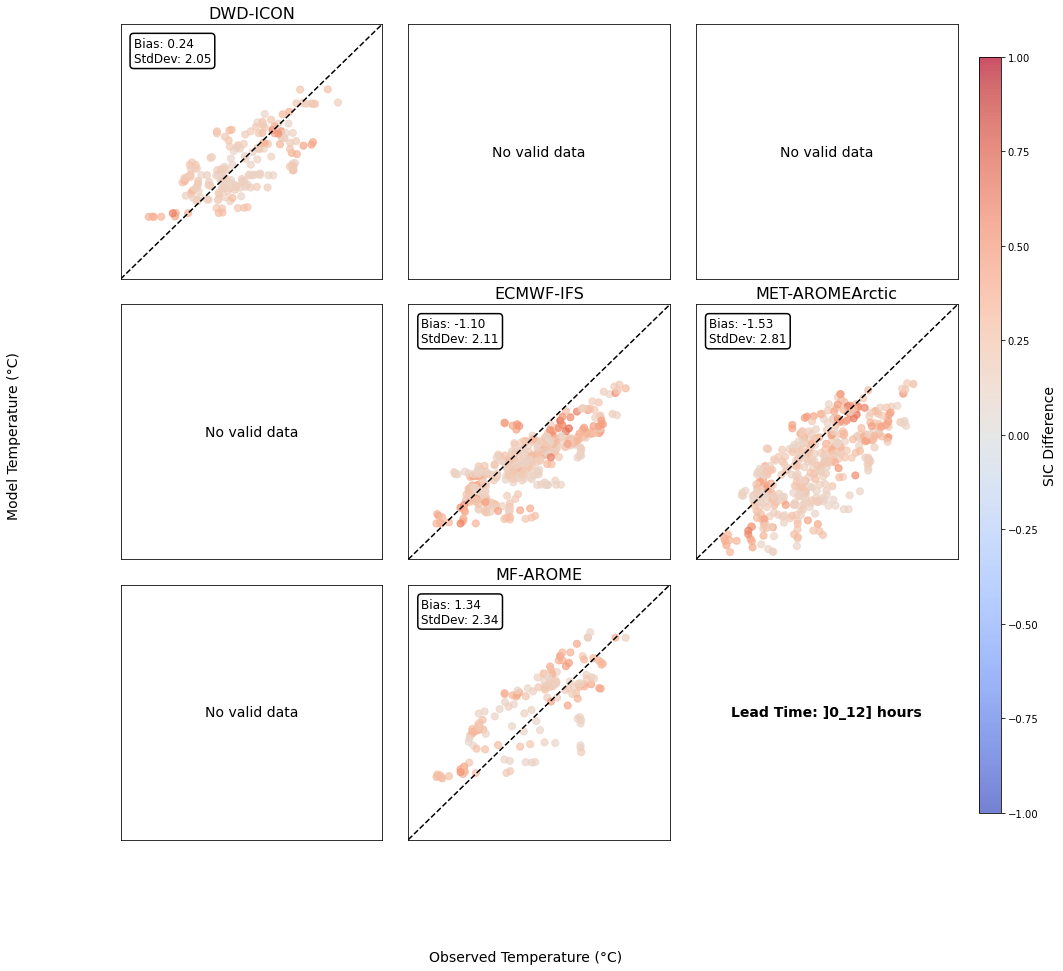

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define figure with 3x3 subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Adjust spacing

# Define the start and end dates
start_date = pd.Timestamp('2024-04-04T00:00:00')
end_date   = pd.Timestamp('2024-04-19T00:00:00')

ldint = 0
time_mask = (OMBtemp.time_ds >= start_date) & (OMBtemp.time_ds <= end_date)

# Storage arrays
all_temp_1m = []
all_temp_models = {}
all_SIC_diff = {}

for model in range(9):  # Loop over 9 models
    row, col = divmod(model, 3)  # Determine subplot position
    ax = axs[row, col]

    all_temp_models[model] = []  # Initialize storage
    all_SIC_diff[model] = []  # Initialize SIC storage

    if model == 8:  # Special case: last plot, add text
        ax.axis("off")  # Hide axes
        lead_time = f"Lead Time: {OMBtemp.lt_int[ldint].values} hours"
        ax.text(0.5, 0.5, lead_time, fontsize=14, ha='center', va='center', fontweight='bold', transform=ax.transAxes)
    else:
        for buoy in range(len(OMBtemp.tr_nr)):
            
            flag3 = OMBtemp.ssdr[5,0,buoy,:].values
            # Radiation needs to be filled between the hours:
            arr_series = pd.Series(flag3)
             # Interpolate missing values
            flag3 = arr_series.interpolate(method='linear').to_numpy()
           
            flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & (flag3 < rad_threshold) & time_mask
     
            temp = OMBtemp.temp_1m_calibrated[buoy, flag_condition.values] - 273.15
            tempmodel = OMBtemp.T2M[model, ldint, buoy, flag_condition.values] - 273.15

            # Calculate SIC difference (model SIC vs observed SIC)
            SIC_model = OMBtemp.SIC[model, ldint, buoy, flag_condition.values]
            SIC_observed = OMBtemp.AMSR2_SIC[buoy, flag_condition.values]
            SIC_diff = SIC_model - SIC_observed  # Difference in SIC

            all_temp_models[model].append(tempmodel.values)  # Store model temp
            all_SIC_diff[model].append(SIC_diff.values)  # Store SIC difference
            
            if model == 0:  # Store observations only once
                all_temp_1m.append(temp.values)

        # Convert to 1D arrays and filter out NaN/Inf
        temp_obs_flat = np.concatenate(all_temp_1m) if all_temp_1m else np.array([])
        temp_model_flat = np.concatenate(all_temp_models[model]) if all_temp_models[model] else np.array([])
        SIC_diff_flat = np.concatenate(all_SIC_diff[model]) if all_SIC_diff[model] else np.array([])

        # Remove NaN/Inf values
        valid_mask = np.isfinite(temp_obs_flat) & np.isfinite(temp_model_flat) & np.isfinite(SIC_diff_flat)
        temp_obs_flat = temp_obs_flat[valid_mask]
        temp_model_flat = temp_model_flat[valid_mask]
        SIC_diff_flat = SIC_diff_flat[valid_mask]
        
        # Ensure there is at least some data
        if len(temp_obs_flat) > 0 and len(temp_model_flat) > 0:
            # Calculate Bias and Standard Deviation
            bias = np.mean(temp_model_flat - temp_obs_flat)
            stde = np.std(temp_model_flat - temp_obs_flat)

            # Set equal axis limits
            temp_min = min(temp_obs_flat.min(), temp_model_flat.min()) - 1
            temp_max = max(temp_obs_flat.max(), temp_model_flat.max()) + 1
            ax.set_xlim(temp_min, temp_max)
            ax.set_ylim(temp_min, temp_max)

            # Scatter plot with color shading based on SIC difference
            sc = ax.scatter(temp_obs_flat[SIC_diff_flat>0.1], temp_model_flat[SIC_diff_flat>0.1], c=SIC_diff_flat[SIC_diff_flat>0.1], cmap='coolwarm', s=50, vmin=-1, vmax=1,alpha=0.7)

            # Plot 1:1 diagonal reference line
            ax.plot([temp_min, temp_max], [temp_min, temp_max], 'k--', linewidth=1.5, label="1:1 Line")

            # Set axis labels
            ax.set_title(f"{OMBtemp.model[model].values}", fontsize=16)

            # Add text box with Bias and Standard Deviation
            textstr = f'Bias: {bias:.2f}\nStdDev: {stde:.2f}'
            props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.5)
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='left', bbox=props)

        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(0.5, 0.5, "No valid data", fontsize=14, ha='center', va='center', transform=ax.transAxes)

# Global labels
fig.supxlabel("Observed Temperature (°C)", fontsize=14)
fig.supylabel("Model Temperature (°C)", fontsize=14)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position colorbar
cbar = plt.colorbar(sc, cax=cbar_ax)
cbar.set_label("SIC Difference", fontsize=14)

# Save figure
filename = f"temp_vs_model_SIC_diff_{start_date}_to_{end_date}_leadtime_{ldint}_sicpositive.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

# Show plot
plt.show()


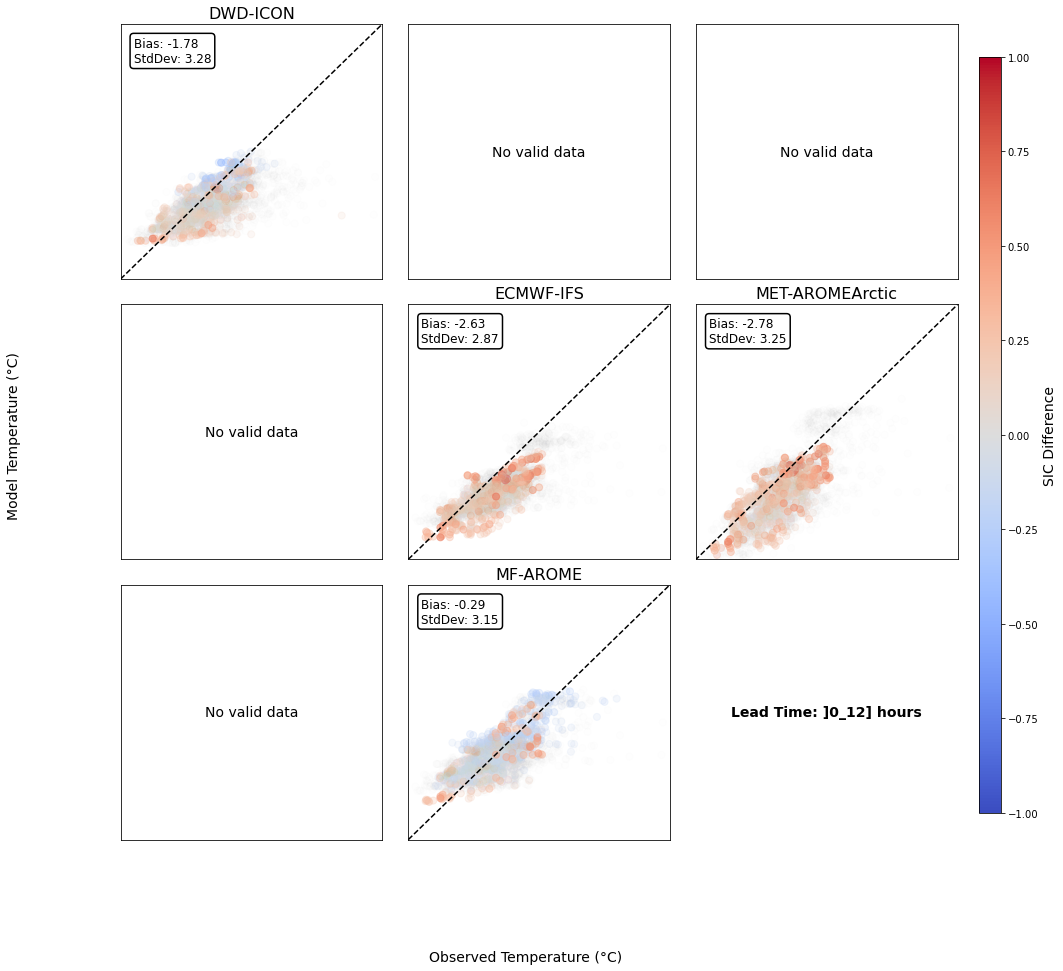

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define figure with 3x3 subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Adjust spacing

# Define the start and end dates
start_date = pd.Timestamp('2024-04-05T00:00:00')
end_date   = pd.Timestamp('2024-04-19T00:00:00')

ldint = 0
time_mask = (OMBtemp.time_ds >= start_date) & (OMBtemp.time_ds <= end_date)

# Storage arrays
all_temp_1m = []
all_temp_models = {}
all_SIC_diff = {}

for model in range(9):  # Loop over 9 models
    row, col = divmod(model, 3)  # Determine subplot position
    ax = axs[row, col]

    all_temp_models[model] = []  # Initialize storage
    all_SIC_diff[model] = []  # Initialize SIC storage

    if model == 8:  # Special case: last plot, add text
        ax.axis("off")  # Hide axes
        lead_time = f"Lead Time: {OMBtemp.lt_int[ldint].values} hours"
        ax.text(0.5, 0.5, lead_time, fontsize=14, ha='center', va='center', fontweight='bold', transform=ax.transAxes)
    else:
        for buoy in range(len(OMBtemp.tr_nr)):
            flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & time_mask

            temp = OMBtemp.temp_1m_calibrated[buoy, flag_condition.values] - 273.15
            tempmodel = OMBtemp.T2M[model, ldint, buoy, flag_condition.values] - 273.15

            # Calculate SIC difference (model SIC vs observed SIC)
            SIC_model = OMBtemp.SIC[model, ldint, buoy, flag_condition.values]
            SIC_observed = OMBtemp.AMSR2_SIC[buoy, flag_condition.values]
            SIC_diff = SIC_model - SIC_observed  # Difference in SIC

            all_temp_models[model].append(tempmodel.values)  # Store model temp
            all_SIC_diff[model].append(SIC_diff.values)  # Store SIC difference
            
            if model == 0:  # Store observations only once
                all_temp_1m.append(temp.values)

        # Convert to 1D arrays and filter out NaN/Inf
        temp_obs_flat = np.concatenate(all_temp_1m) if all_temp_1m else np.array([])
        temp_model_flat = np.concatenate(all_temp_models[model]) if all_temp_models[model] else np.array([])
        SIC_diff_flat = np.concatenate(all_SIC_diff[model]) if all_SIC_diff[model] else np.array([])

        # Remove NaN/Inf values
        valid_mask = np.isfinite(temp_obs_flat) & np.isfinite(temp_model_flat) & np.isfinite(SIC_diff_flat)
        temp_obs_flat = temp_obs_flat[valid_mask]
        temp_model_flat = temp_model_flat[valid_mask]
        SIC_diff_flat = SIC_diff_flat[valid_mask]

        # Ensure there is at least some data
        if len(temp_obs_flat) > 0 and len(temp_model_flat) > 0:
            # Calculate Bias and Standard Deviation
            bias = np.mean(temp_model_flat - temp_obs_flat)
            stde = np.std(temp_model_flat - temp_obs_flat)

            # Set equal axis limits
            temp_min = min(temp_obs_flat.min(), temp_model_flat.min()) - 1
            temp_max = max(temp_obs_flat.max(), temp_model_flat.max()) + 1
            ax.set_xlim(temp_min, temp_max)
            ax.set_ylim(temp_min, temp_max)

            # Calculate alpha (transparency) based on SIC difference
            alpha_values = np.clip(np.abs(SIC_diff_flat), 0, 1)  # Set alpha based on SIC difference
            alpha_values[(SIC_diff_flat >= -0.15) & (SIC_diff_flat <= 0.15)] = 0.01  # More transparent for SIC_diff between -0.15 and 0.15

            # Scatter plot with color shading based on SIC difference
            sc = ax.scatter(temp_obs_flat, temp_model_flat, c=SIC_diff_flat, cmap='coolwarm', s=50, 
                            vmin=-1, vmax=1, alpha=alpha_values)

            # Plot 1:1 diagonal reference line
            ax.plot([temp_min, temp_max], [temp_min, temp_max], 'k--', linewidth=1.5, label="1:1 Line")

            # Set axis labels
            ax.set_title(f"{OMBtemp.model[model].values}", fontsize=16)

            # Add text box with Bias and Standard Deviation
            textstr = f'Bias: {bias:.2f}\nStdDev: {stde:.2f}'
            props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.5)
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='left', bbox=props)

        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(0.5, 0.5, "No valid data", fontsize=14, ha='center', va='center', transform=ax.transAxes)

# Global labels
fig.supxlabel("Observed Temperature (°C)", fontsize=14)
fig.supylabel("Model Temperature (°C)", fontsize=14)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position colorbar
cbar = plt.colorbar(sc, cax=cbar_ax)
cbar.set_label("SIC Difference", fontsize=14)

# Save figure
filename = f"temp_vs_model_SIC_diff_{start_date}_to_{end_date}_leadtime_{ldint}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define figure with 3x3 subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Adjust spacing

# Define the start and end dates
start_date = pd.Timestamp('2024-04-04T00:00:00')
end_date   = pd.Timestamp('2024-04-19T00:00:00')

ldint = 3  # 36-48 hour leadtime
time_mask = (OMBtemp.time_ds >= start_date) & (OMBtemp.time_ds <= end_date)

# Storage arrays
all_temp_1m = []
all_temp_models = {}
all_SIC_diff = {}

for model in range(9):  # Loop over 9 models
    row, col = divmod(model, 3)  # Determine subplot position
    ax = axs[row, col]

    all_temp_models[model] = []  # Initialize storage
    all_SIC_diff[model] = []  # Initialize SIC storage

    if model == 8:  # Special case: last plot, add text
        ax.axis("off")  # Hide axes
        lead_time = f"Lead Time: {OMBtemp.lt_int[ldint].values} hours"
        ax.text(0.5, 0.5, lead_time, fontsize=14, ha='center', va='center', fontweight='bold', transform=ax.transAxes)
    else:
        for buoy in range(len(OMBtemp.tr_nr)):
            
            flag3 = OMBtemp.ssdr[5,0,buoy,:].values
            # Radiation needs to be filled between the hours:
            arr_series = pd.Series(flag3)
             # Interpolate missing values
            flag3 = arr_series.interpolate(method='linear').to_numpy()
           
            flag_condition = (OMBtemp.temp_flag_1m[buoy, :] == 0) & (OMBtemp.temp_flag_cons[buoy, :] == 0) & (flag3 < rad_threshold) & time_mask
     
            temp = OMBtemp.temp_1m_calibrated[buoy, flag_condition.values] - 273.15
            tempmodel = OMBtemp.T2M[model, ldint, buoy, flag_condition.values] - 273.15

            # Calculate SIC difference (model SIC vs observed SIC)
            SIC_model = OMBtemp.SIC[model, ldint, buoy, flag_condition.values]
            SIC_observed = OMBtemp.AMSR2_SIC[buoy, flag_condition.values]
            SIC_diff = SIC_model - SIC_observed  # Difference in SIC

            all_temp_models[model].append(tempmodel.values)  # Store model temp
            all_SIC_diff[model].append(SIC_diff.values)  # Store SIC difference
            
            if model == 0:  # Store observations only once
                all_temp_1m.append(temp.values)

        # Convert to 1D arrays and filter out NaN/Inf
        temp_obs_flat = np.concatenate(all_temp_1m) if all_temp_1m else np.array([])
        temp_model_flat = np.concatenate(all_temp_models[model]) if all_temp_models[model] else np.array([])
        SIC_diff_flat = np.concatenate(all_SIC_diff[model]) if all_SIC_diff[model] else np.array([])

        # Remove NaN/Inf values
        valid_mask = np.isfinite(temp_obs_flat) & np.isfinite(temp_model_flat) & np.isfinite(SIC_diff_flat)
        temp_obs_flat = temp_obs_flat[valid_mask]
        temp_model_flat = temp_model_flat[valid_mask]
        SIC_diff_flat = SIC_diff_flat[valid_mask]
        
        # Ensure there is at least some data
        if len(temp_obs_flat) > 0 and len(temp_model_flat) > 0:
            # Calculate Bias and Standard Deviation
            bias = np.mean(temp_model_flat - temp_obs_flat)
            stde = np.std(temp_model_flat - temp_obs_flat)

            # Set equal axis limits
            temp_min = min(temp_obs_flat.min(), temp_model_flat.min()) - 1
            temp_max = max(temp_obs_flat.max(), temp_model_flat.max()) + 1
            ax.set_xlim(temp_min, temp_max)
            ax.set_ylim(temp_min, temp_max)

            # Scatter plot with color shading based on SIC difference
            sc = ax.scatter(temp_obs_flat[SIC_diff_flat>0.1], temp_model_flat[SIC_diff_flat>0.1], c=SIC_diff_flat[SIC_diff_flat>0.1], cmap='coolwarm', s=50, vmin=-1, vmax=1,alpha=0.7)

            # Plot 1:1 diagonal reference line
            ax.plot([temp_min, temp_max], [temp_min, temp_max], 'k--', linewidth=1.5, label="1:1 Line")

            # Set axis labels
            ax.set_title(f"{OMBtemp.model[model].values}", fontsize=16)

            # Add text box with Bias and Standard Deviation
            textstr = f'Bias: {bias:.2f}\nStdDev: {stde:.2f}'
            props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.5)
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='left', bbox=props)

        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(0.5, 0.5, "No valid data", fontsize=14, ha='center', va='center', transform=ax.transAxes)

# Global labels
fig.supxlabel("Observed Temperature (°C)", fontsize=14)
fig.supylabel("Model Temperature (°C)", fontsize=14)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position colorbar
cbar = plt.colorbar(sc, cax=cbar_ax)
cbar.set_label("SIC Difference", fontsize=14)

# Save figure
filename = f"temp_vs_model_SIC_diff_{start_date}_to_{end_date}_leadtime_{ldint}_sicpositive.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

# Show plot
plt.show()

In [37]:
flag3

array([        nan,         nan,         nan, ..., 62.56000137,
       62.56000137, 62.56000137])

In [33]:
OMBtemp.model

<xarray.DataArray 'model' (model: 8)>
array(['DWD-ICON', 'ECCC-HRDPSN', 'ECCC-HRDPSNcoupled', 'ECMWF-AIFS',
       'ECMWF-IFS', 'MET-AROMEArctic', 'MF-AROME', 'MF-ARPEGE'], dtype=object)
Coordinates:
  * model    (model) object 'DWD-ICON' 'ECCC-HRDPSN' ... 'MF-AROME' 'MF-ARPEGE'